# Stock Returns Dashboard

**Author:** Masters in Finance | Asset Management & Quant Research  
**Universe:** AAPL · AMZN · BLK · BND · GLD · JPM · MSFT · QQQ · SPY · XOM  
**Period:** January 2022 – December 2024  
**Data source:** Yahoo Finance via `yfinance`

---

This dashboard analyses three years of daily price data across equities, fixed income, and commodities.  
Sections covered:
1. Correlation Heatmap
2. Annualized Returns
3. Annualized Volatility
4. Cumulative Returns ($1 invested)
5. Summary Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.4,
})
sns.set_theme(style='whitegrid', palette='tab10')

# ── Consistent 10-ticker colour palette ───────────────────────────────────────
PALETTE = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]

# ── Load data ─────────────────────────────────────────────────────────────────
prices  = pd.read_csv('prices.csv',  index_col='Date', parse_dates=True)
returns = pd.read_csv('returns.csv', index_col='Date', parse_dates=True)

TICKERS  = prices.columns.tolist()
COLOR_MAP = dict(zip(TICKERS, PALETTE))

# ── Pre-compute key metrics (reused across sections) ──────────────────────────
ann_ret = returns.mean() * 252 * 100          # annualised return (%)
ann_vol = returns.std()  * np.sqrt(252) * 100 # annualised volatility (%)
sharpe  = ann_ret / ann_vol                   # approx. Sharpe (rf = 0)

print(f'Tickers : {TICKERS}')
print(f'Period  : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Days    : {len(prices)}')

Tickers : ['AAPL', 'AMZN', 'BLK', 'BND', 'GLD', 'JPM', 'MSFT', 'QQQ', 'SPY', 'XOM']
Period  : 2022-01-03 → 2024-12-30
Days    : 752


---
## Section 1 · Correlation Heatmap

Pairwise Pearson correlation of daily returns.  
Values close to **+1** move in lockstep; values close to **0** are uncorrelated; **negative** values hedge each other.  
Lower-triangle only to avoid redundancy.

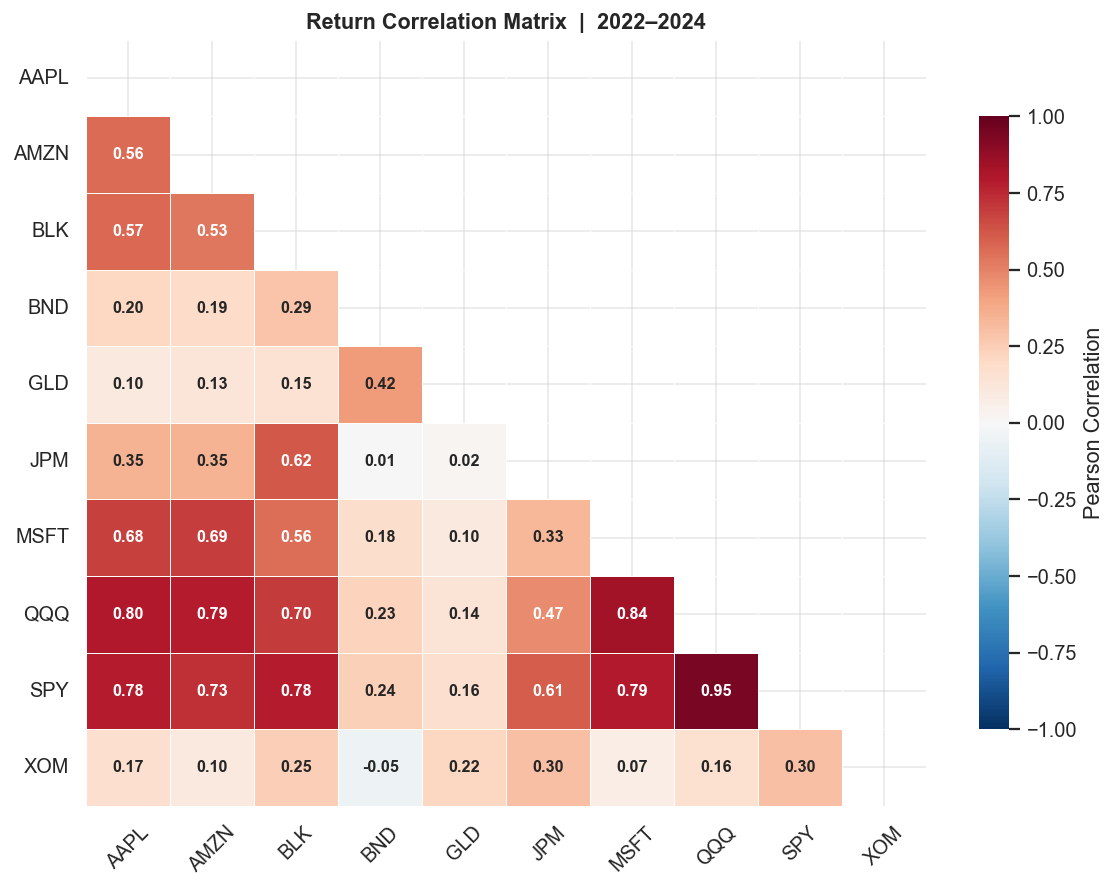

In [2]:
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Return Correlation Matrix  |  2022–2024')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**Key observations:**
- Tech stocks (AAPL, AMZN, MSFT, QQQ) are highly correlated — limited diversification benefit within the group.
- BND (bonds) and GLD (gold) show low-to-negative correlation with equities — valuable diversifiers.
- SPY and QQQ correlate strongly, as QQQ is a tech-heavy S&P proxy.

---
## Section 2 · Annualized Returns

Average daily return scaled to an annual figure (×252 trading days).  
Green bars = positive return; red bars = negative return.

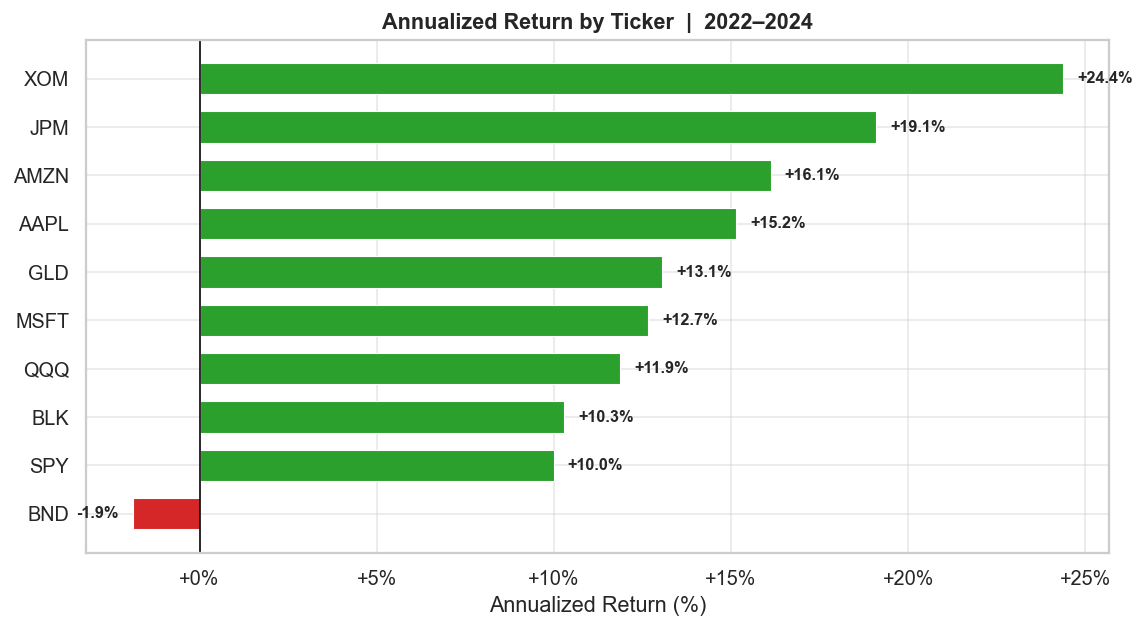

In [3]:
sorted_ret = ann_ret.sort_values()
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in sorted_ret]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_ret.index, sorted_ret.values, color=bar_colors,
               edgecolor='white', linewidth=0.6, height=0.65)

# Value labels on bars
for bar, val in zip(bars, sorted_ret.values):
    offset = 0.4 if val >= 0 else -0.4
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.9, linestyle='-')
ax.set_xlabel('Annualized Return (%)')
ax.set_title('Annualized Return by Ticker  |  2022–2024')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
plt.tight_layout()
plt.show()

---
## Section 3 · Annualized Volatility

Standard deviation of daily returns scaled to annual (×√252).  
Higher volatility = wider distribution of outcomes = more risk.

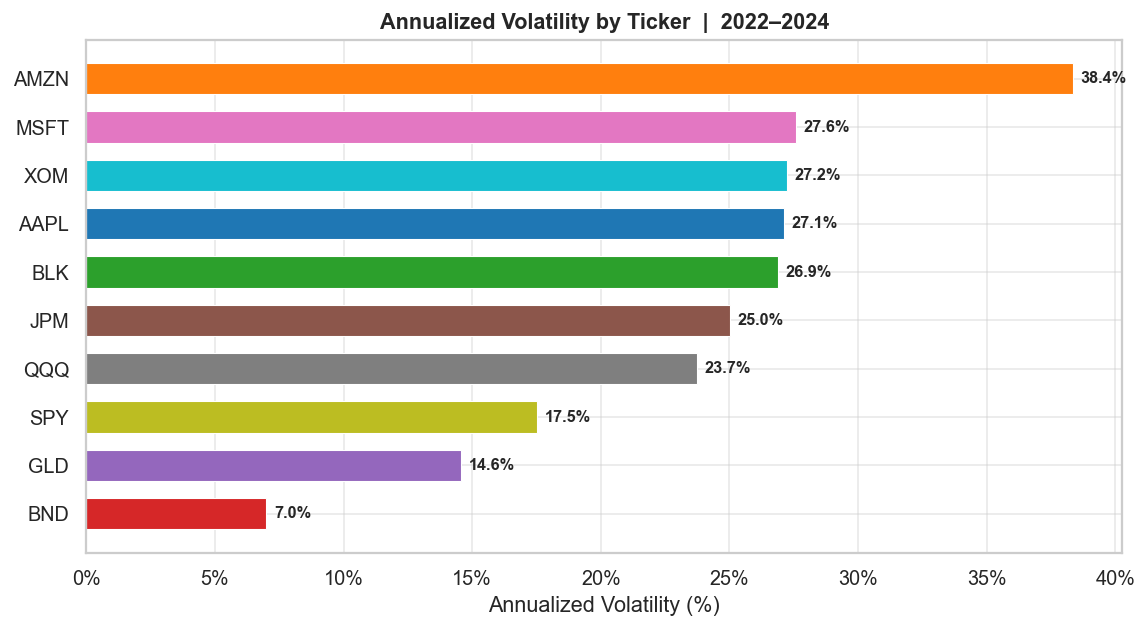

In [4]:
sorted_vol = ann_vol.sort_values()
vol_colors = [COLOR_MAP[t] for t in sorted_vol.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_vol.index, sorted_vol.values, color=vol_colors,
               edgecolor='white', linewidth=0.6, height=0.65)

for bar, val in zip(bars, sorted_vol.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Annualized Volatility (%)')
ax.set_title('Annualized Volatility by Ticker  |  2022–2024')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

---
## Section 4 · Cumulative Returns ($1 Invested)

Tracks the growth of **$1 invested** in each ticker from January 2022.  
Equivalent to a buy-and-hold strategy with no transaction costs or dividends reinvested.

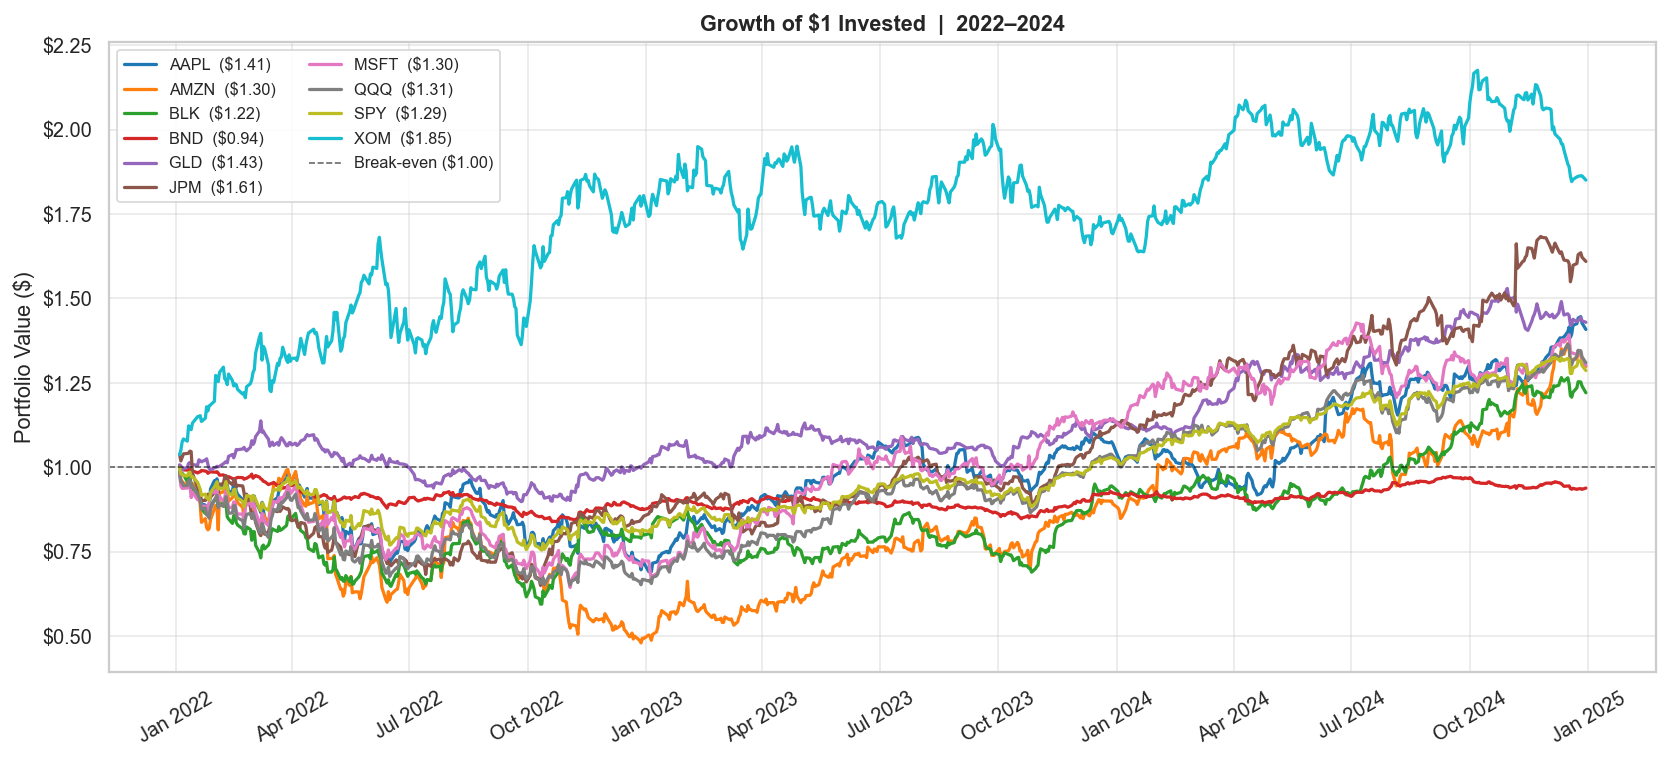

In [5]:
growth = (1 + returns).cumprod()  # $1 grows to this value

fig, ax = plt.subplots(figsize=(13, 6))

for ticker in TICKERS:
    final_val = growth[ticker].iloc[-1]
    ax.plot(growth.index, growth[ticker],
            label=f'{ticker}  (${final_val:.2f})',
            color=COLOR_MAP[ticker], linewidth=1.8)

ax.axhline(1.0, color='black', linewidth=0.9, linestyle='--', alpha=0.6,
           label='Break-even ($1.00)')

ax.set_title('Growth of $1 Invested  |  2022–2024')
ax.set_ylabel('Portfolio Value ($)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(loc='upper left', ncol=2, fontsize=9,
          framealpha=0.85, edgecolor='lightgrey')
plt.tight_layout()
plt.show()

---
## Section 5 · Summary Statistics

Consolidated performance table sorted by annualized return.  
**Sharpe Ratio** = Ann. Return / Ann. Volatility (risk-free rate assumed = 0 for simplicity).  
Color gradients: green = better, red = worse.

In [6]:
# Max drawdown per ticker
max_dd = {}
for t in TICKERS:
    cum = (1 + returns[t]).cumprod()
    max_dd[t] = ((cum - cum.cummax()) / cum.cummax()).min() * 100

# Total return over the full period
total_ret = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

summary = pd.DataFrame({
    'Total Return (%)':    total_ret,
    'Ann. Return (%)':     ann_ret,
    'Ann. Volatility (%)': ann_vol,
    'Sharpe Ratio':        sharpe,
    'Max Drawdown (%)':    pd.Series(max_dd),
}).sort_values('Ann. Return (%)', ascending=False)

(
    summary.style
    .format({
        'Total Return (%)':    '{:+.1f}%',
        'Ann. Return (%)':     '{:+.1f}%',
        'Ann. Volatility (%)': '{:.1f}%',
        'Sharpe Ratio':        '{:.2f}',
        'Max Drawdown (%)':    '{:.1f}%',
    })
    .background_gradient(subset=['Total Return (%)', 'Ann. Return (%)'],
                         cmap='RdYlGn', vmin=-20, vmax=60)
    .background_gradient(subset=['Ann. Volatility (%)'],
                         cmap='YlOrRd_r', vmin=10, vmax=45)
    .background_gradient(subset=['Sharpe Ratio'],
                         cmap='RdYlGn', vmin=-0.5, vmax=1.5)
    .background_gradient(subset=['Max Drawdown (%)'],
                         cmap='RdYlGn', vmin=-60, vmax=0)
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('font-size', '11px'),
                  ('text-align', 'center'), ('background-color', '#f0f4f8')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center'), ('font-size', '11px')]
    }])
    .set_caption('Summary Statistics · 2022–2024  (sorted by Ann. Return)')
)

,Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
XOM,+85.1%,+24.4%,27.2%,0.89,-20.5%
JPM,+61.0%,+19.1%,25.0%,0.76,-37.9%
AMZN,+29.9%,+16.1%,38.4%,0.42,-51.7%
AAPL,+40.8%,+15.2%,27.1%,0.56,-30.0%
GLD,+43.0%,+13.1%,14.6%,0.90,-21.0%
MSFT,+30.2%,+12.7%,27.6%,0.46,-34.5%
QQQ,+31.0%,+11.9%,23.7%,0.50,-34.0%
BLK,+22.1%,+10.3%,26.9%,0.38,-40.9%
SPY,+28.7%,+10.0%,17.5%,0.57,-24.5%
BND,-6.1%,-1.9%,7.0%,-0.27,-16.1%


---

### Additional Charts (supporting analysis)

The following charts supplement the five core sections with deeper views into rolling risk and drawdown dynamics.

#### Risk–Return Scatter

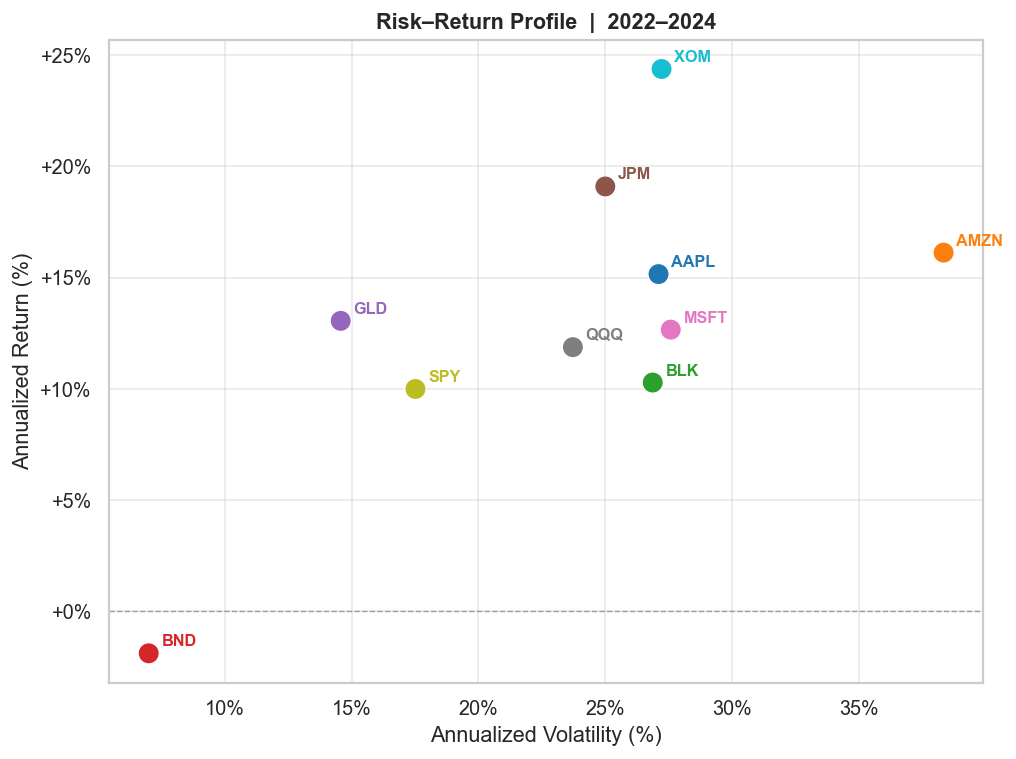

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(ann_vol, ann_ret,
                     c=[COLOR_MAP[t] for t in TICKERS], s=140, zorder=3,
                     edgecolors='white', linewidth=0.8)

for ticker in TICKERS:
    ax.annotate(ticker, (ann_vol[ticker], ann_ret[ticker]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=9, fontweight='bold', color=COLOR_MAP[ticker])

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Risk–Return Profile  |  2022–2024')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
plt.tight_layout()
plt.show()

#### Rolling 30-Day Volatility

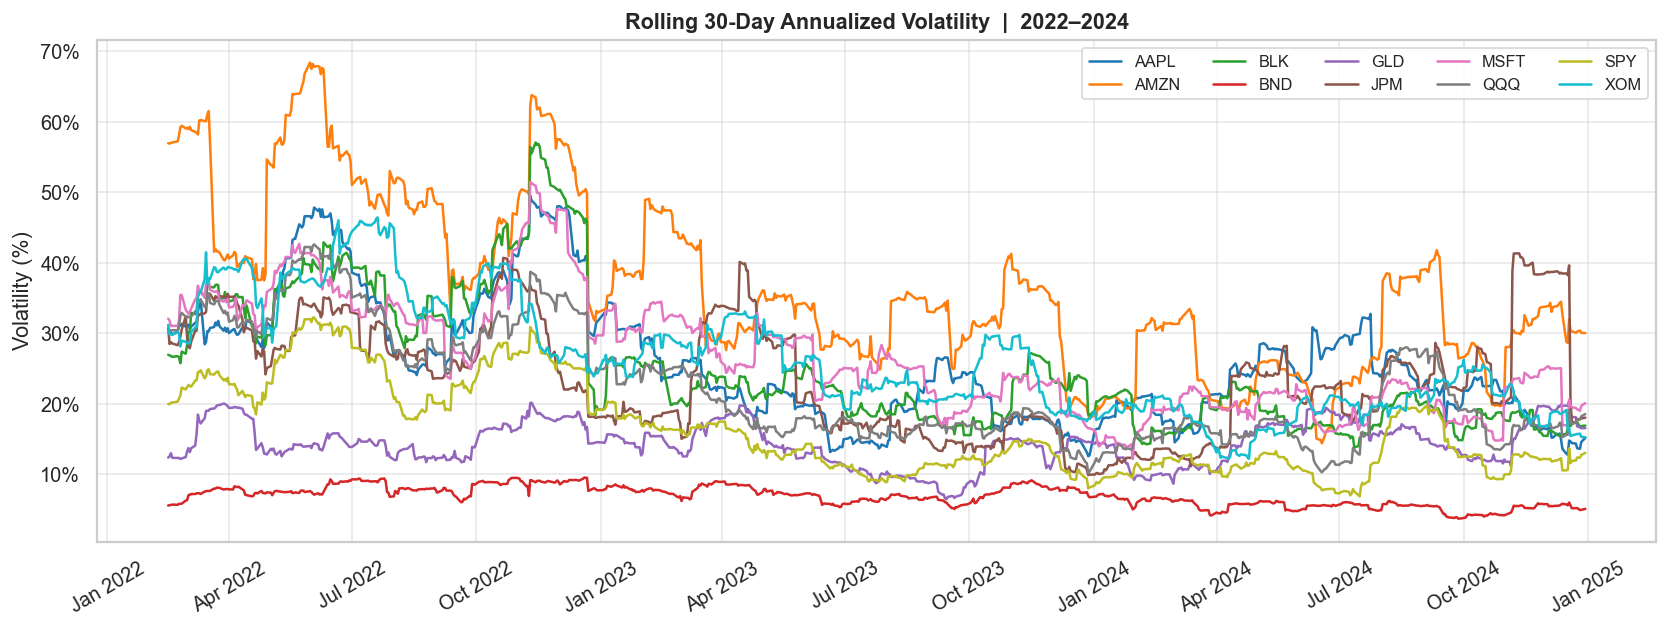

In [8]:
roll_vol = returns.rolling(30).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for ticker in TICKERS:
    ax.plot(roll_vol.index, roll_vol[ticker], label=ticker,
            color=COLOR_MAP[ticker], linewidth=1.4)

ax.set_title('Rolling 30-Day Annualized Volatility  |  2022–2024')
ax.set_ylabel('Volatility (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(loc='upper right', ncol=5, fontsize=9,
          framealpha=0.85, edgecolor='lightgrey')
plt.tight_layout()
plt.show()

#### Drawdown from Peak

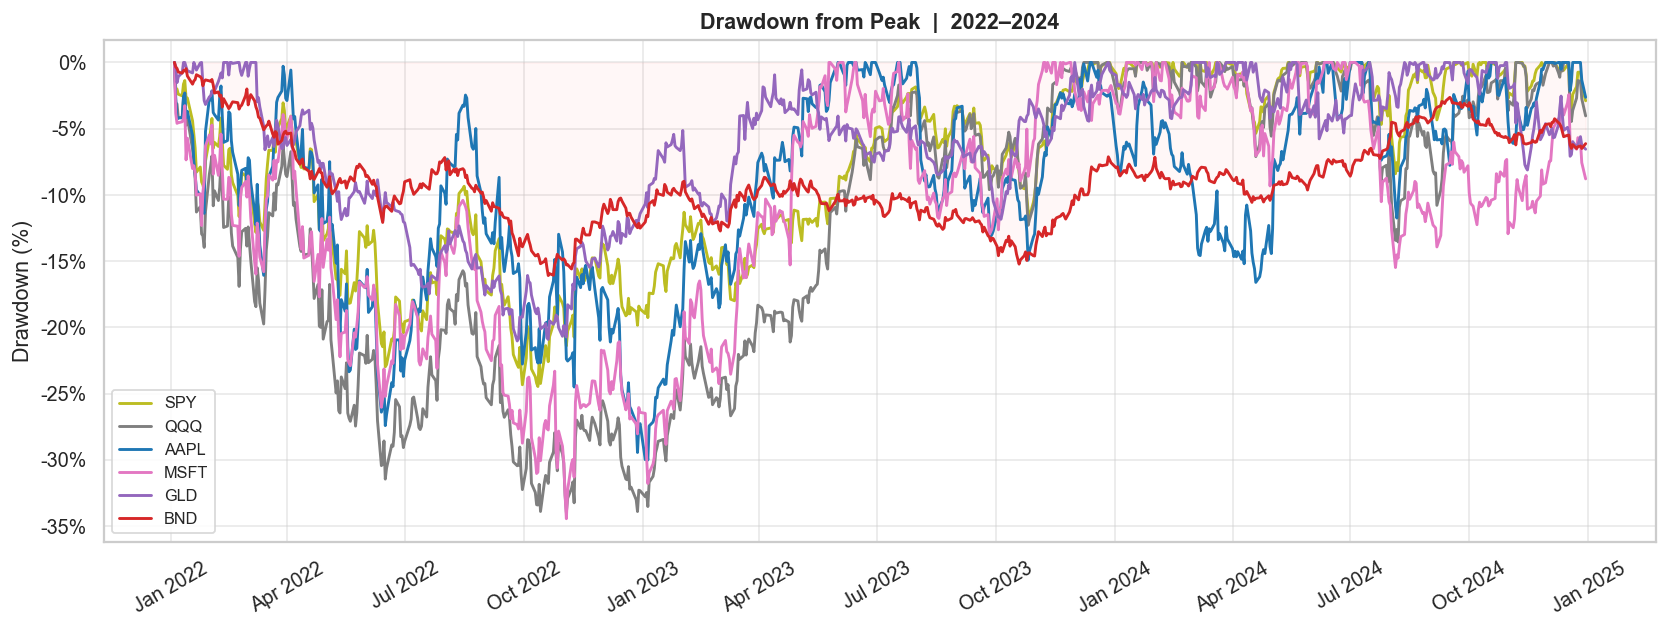

In [9]:
HIGHLIGHT = ['SPY', 'QQQ', 'AAPL', 'MSFT', 'GLD', 'BND']

fig, ax = plt.subplots(figsize=(13, 5))
for ticker in HIGHLIGHT:
    cum = (1 + returns[ticker]).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.plot(dd.index, dd, label=ticker,
            color=COLOR_MAP[ticker], linewidth=1.6)

ax.fill_between(dd.index, dd, 0, alpha=0.03, color='red')
ax.set_title('Drawdown from Peak  |  2022–2024')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
ax.legend(fontsize=9, framealpha=0.85, edgecolor='lightgrey')
plt.tight_layout()
plt.show()

#### SPY Monthly Returns Heatmap

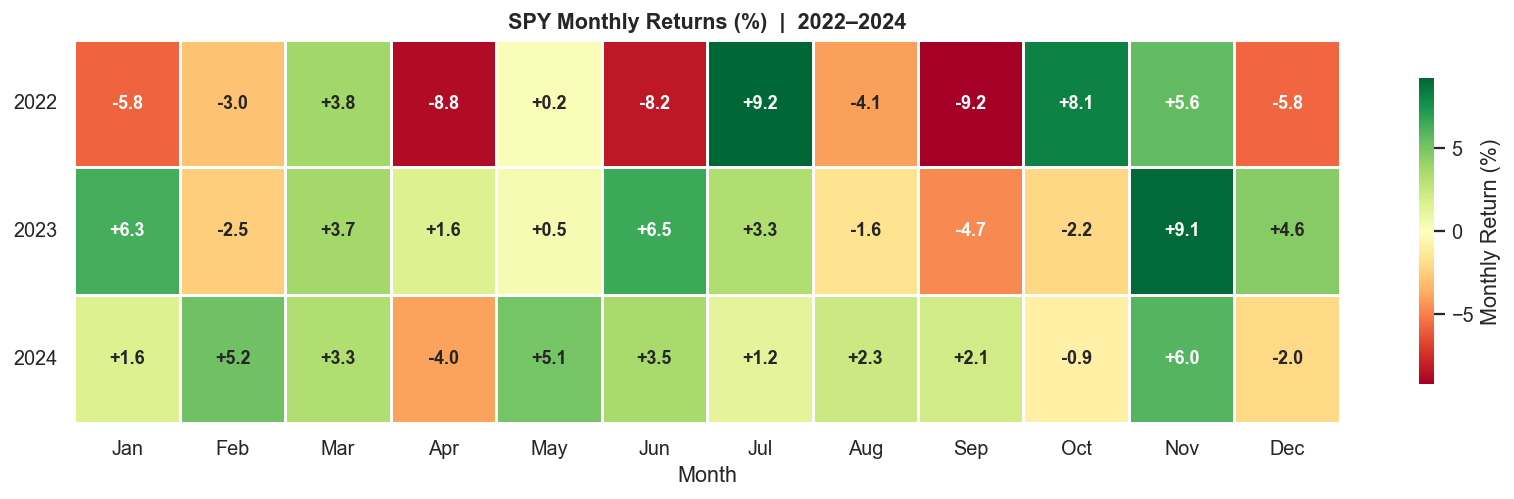

In [10]:
TICKER = 'SPY'
monthly = (returns[TICKER].resample('ME')
           .apply(lambda x: (1 + x).prod() - 1) * 100)
df_m = monthly.to_frame()
df_m['Year']  = df_m.index.year
df_m['Month'] = df_m.index.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
heat = (df_m.pivot_table(index='Year', columns='Month', values=TICKER)
        .reindex(columns=month_order))

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat, annot=True, fmt='+.1f', cmap='RdYlGn', center=0,
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.8})
ax.set_title(f'{TICKER} Monthly Returns (%)  |  2022–2024')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()